In [ ]:
import os

import pandas as pd
from pathlib import Path

os.chdir(r"/home/enzo-maldinni/Documentos/SIGAMA-data-analysis")
print(os.getcwd())

from src.utils.parsing import parse_args, load_config

import sys
sys.argv = [sys.argv[0]]

args = parse_args()
cfg = load_config(args)

paths = cfg["paths"]

clusters_path = f'{cfg["paths"]["processed"]}'

print(clusters_path)

solicitacoes_file = Path(clusters_path) / "clusters_solicitacoes_defined_distinguished_trends.csv"

print(solicitacoes_file)


/home/enzo-maldinni/Documentos/SIGAMA-data-analysis
data/processed
data/processed/clusters_solicitacoes_defined_distinguished_trends.csv


In [ ]:
import pandas as pd
import re
import unicodedata

def normalize_text(text):
    if pd.isna(text):
        return text
    
    # remover acentos
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")
    
    # lowercase
    text = text.lower()
    
    # remover hífen no início
    text = re.sub(r"^-+", "", text)
    
    # remover pontuação
    text = re.sub(r"[^\w\s]", "", text)
    
    # remover espaços extras
    text = re.sub(r"\s+", " ", text)
    
    text = text.strip()
    
    # capitalizar
    text = text.capitalize()
    
    return text

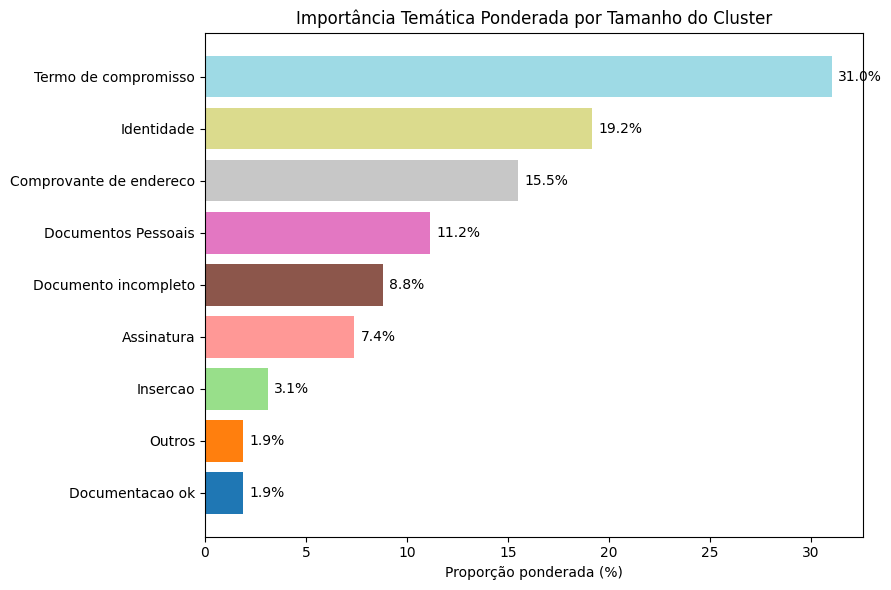

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(solicitacoes_file)

focus_map = {
    "Termo de responsabilidade": "Termo de compromisso",
    "Termo de Responsabilidade": "Termo de compromisso",
    "Comprovante de endereço": "Comprovante de Endereço",
    "Documentos pessoais": "Documentos Pessoais",
    "Documentação": "Documentos Pessoais",
    "Documentos": "Documentos Pessoais",
    "Faltando": "Falta"
}

# separar múltiplos temas
focus_expanded = (
    df[["Focus", "Size"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

# limpar espaços
focus_expanded["Focus"] = focus_expanded["Focus"].str.strip().apply(normalize_text).replace(focus_map)

# somar Size por tema
focus_weighted = (
    focus_expanded
    .groupby("Focus")["Size"]
    .sum()
    .sort_values(ascending=False)
)

# pegar top 10
top10 = focus_weighted.head(8)

# agrupar restante
others = focus_weighted.iloc[8:].sum()

plot_data = pd.concat([top10, pd.Series({"Outros": others})])

# converter para proporção
plot_data_pct = plot_data / plot_data.sum() * 100

# ordenar para visualização
plot_data_pct = plot_data_pct.sort_values()

# cores
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_data_pct)))

# gráfico
plt.figure(figsize=(9,6))

bars = plt.barh(plot_data_pct.index, plot_data_pct.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             va='center')

plt.xlabel("Proporção ponderada (%)")
plt.title("Importância Temática Ponderada por Tamanho do Cluster")

plt.tight_layout()
plt.show()



datetime64[us, UTC]


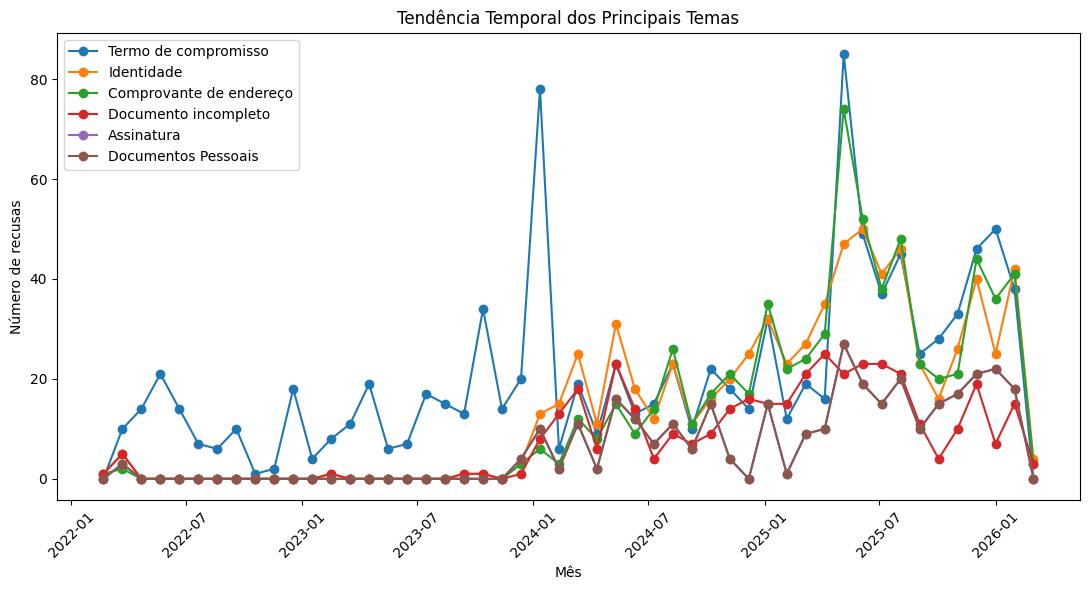

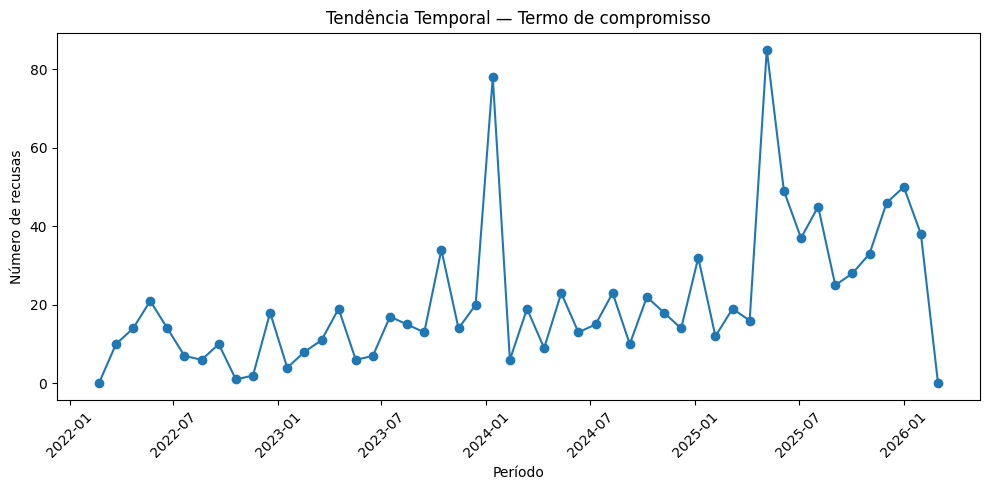

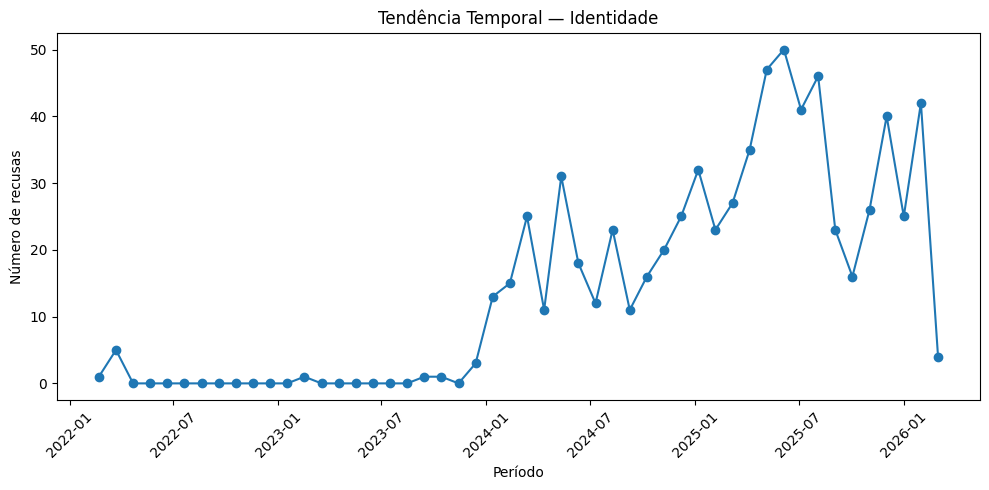

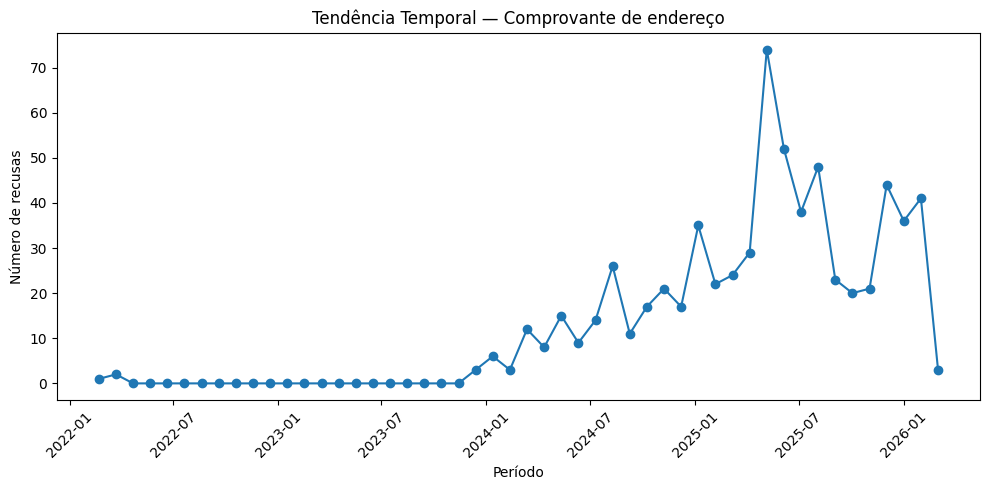

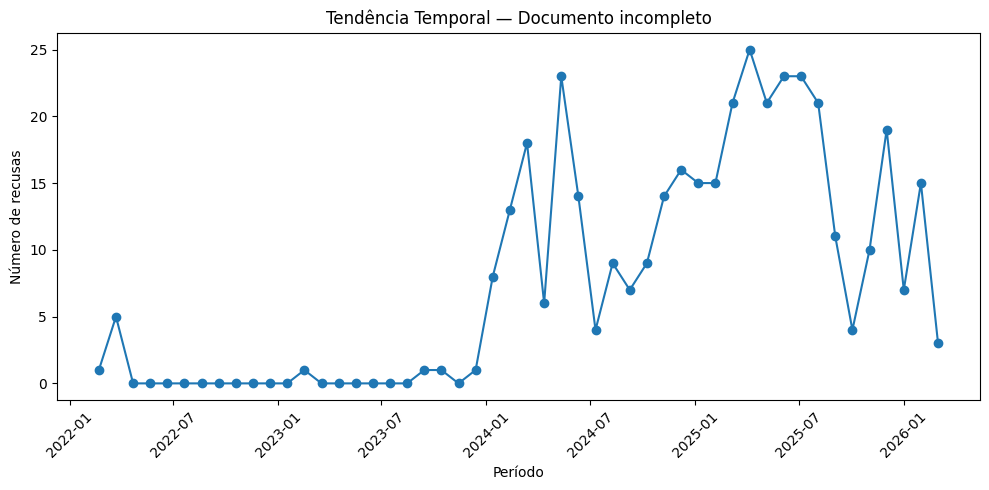

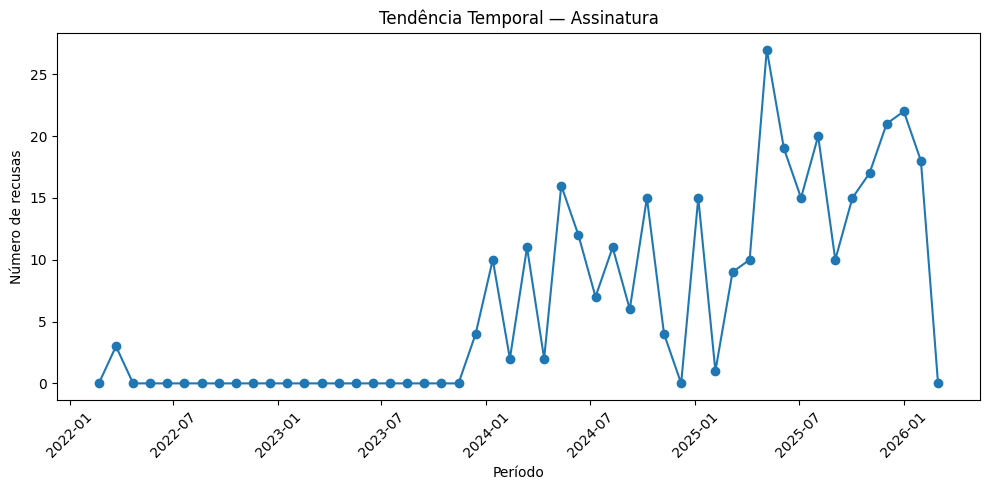

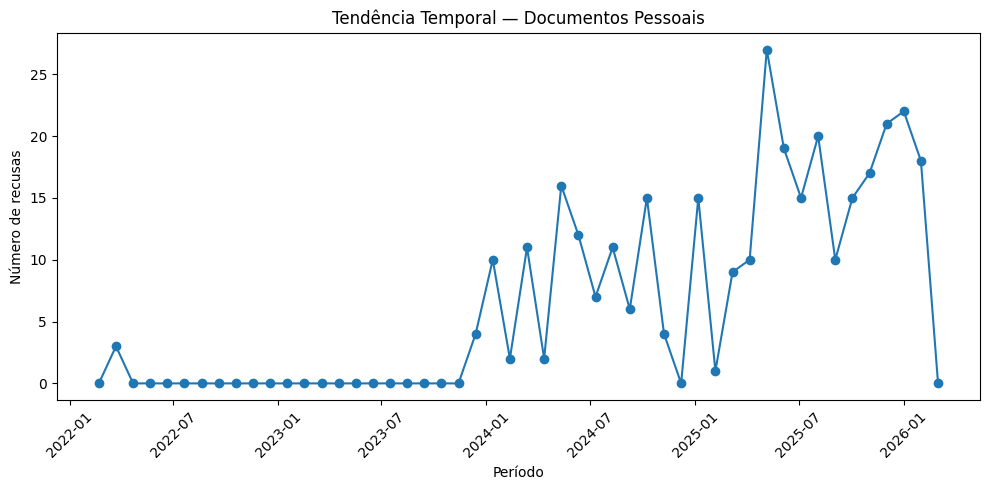

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# carregar datasets
articles_file = Path(clusters_path) / "primeiro_acesso_historico_202603041232_limpo_llm_clustered.csv"

news_df = pd.read_csv(articles_file)
clusters_df = pd.read_csv(solicitacoes_file)

# converter datas
# converter datas (forma robusta)
news_df["dt_cadastro"] = pd.to_datetime(
    news_df["dt_cadastro"],
    errors="coerce",
    utc=True
)

# remover datas inválidas
news_df = news_df.dropna(subset=["dt_cadastro"])

print(news_df["dt_cadastro"].dtype)

# remover timezone
news_df["dt_cadastro"] = news_df["dt_cadastro"].dt.tz_localize(None)

# criar coluna mês
news_df["month"] = news_df["dt_cadastro"].dt.to_period("M")

# juntar artigos com clusters
# filtrar datas
news_df = news_df[news_df["dt_cadastro"] >= "2022-01-01"]

news_df["period"] = news_df["dt_cadastro"]

merged = news_df.merge(
    clusters_df[["Cluster ID", "Focus"]],
    on="Cluster ID",
    how="left"
)

focus_expanded = (
    merged[["period", "Focus"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

focus_expanded["Focus"] = focus_expanded["Focus"].str.strip()

trend = (
    focus_expanded
    .groupby([pd.Grouper(key="period", freq="30D"), "Focus"])
    .size()
    .reset_index(name="count")
)

trend_pivot = trend.pivot(index="period", columns="Focus", values="count").fillna(0)

# ordenar cronologicamente
trend_pivot = trend_pivot.sort_index()

# principais temas
top_topics = focus_expanded["Focus"].value_counts().head(6).index
trend_top = trend_pivot[top_topics]

# plot
plt.figure(figsize=(11,6))

for col in trend_top.columns:
    plt.plot(trend_top.index, trend_top[col], marker="o", label=col)

plt.xticks(rotation=45)
plt.ylabel("Número de solicitações")
plt.xlabel("Mês")
plt.title("Tendência Temporal dos Principais Temas")
plt.legend()

plt.tight_layout()
plt.show()

for topic in top_topics:
    
    plt.figure(figsize=(10,5))
    
    plt.plot(
        trend_top.index,
        trend_top[topic],
        marker="o"
    )
    
    plt.xticks(rotation=45)
    plt.ylabel("Número de solicitações")
    plt.xlabel("Período")
    plt.title(f"Tendência Temporal — {topic}")
    
    plt.tight_layout()
    plt.show()

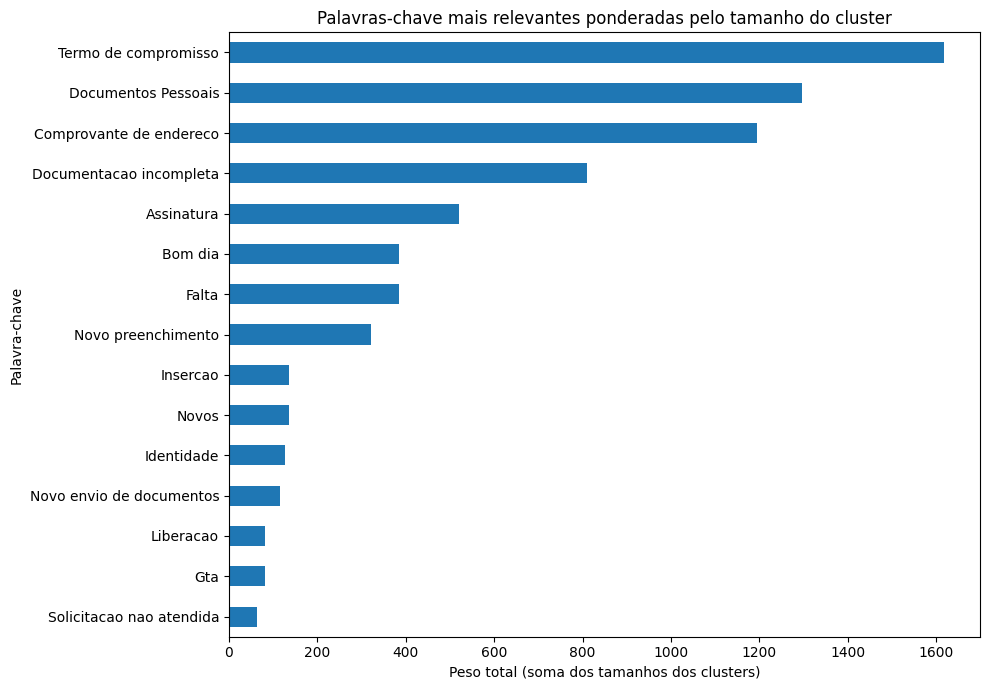

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

focus_map = {
    "Termo de responsabilidade": "Termo de compromisso",
    "Termo de Responsabilidade": "Termo de compromisso",
    "Comprovante de endereço": "Comprovante de Endereço",
    "Documentos pessoais": "Documentos Pessoais",
    "Documentação": "Documentos Pessoais",
    "Documentacao": "Documentos Pessoais",
    "Documentos": "Documentos Pessoais",
    "Faltando": "Falta"
}
keywords_expanded = (
    clusters_df[["Keywords", "Size"]]
    .dropna()
    .assign(Keywords=lambda x: x["Keywords"].str.split(";"))
    .explode("Keywords")
)

keywords_expanded["Keywords"] = keywords_expanded["Keywords"].str.strip().apply(normalize_text).replace(focus_map)

keyword_weight = (
    keywords_expanded
    .groupby("Keywords")["Size"]
    .sum()
    .sort_values(ascending=False)
)

top_keywords = keyword_weight.head(20)

plt.figure(figsize=(10,7))

top_keywords.sort_values().plot(kind="barh")

plt.xlabel("Peso total (soma dos tamanhos dos clusters)")
plt.ylabel("Palavra-chave")
plt.title("Palavras-chave mais relevantes ponderadas pelo tamanho do cluster")

plt.tight_layout()
plt.show()

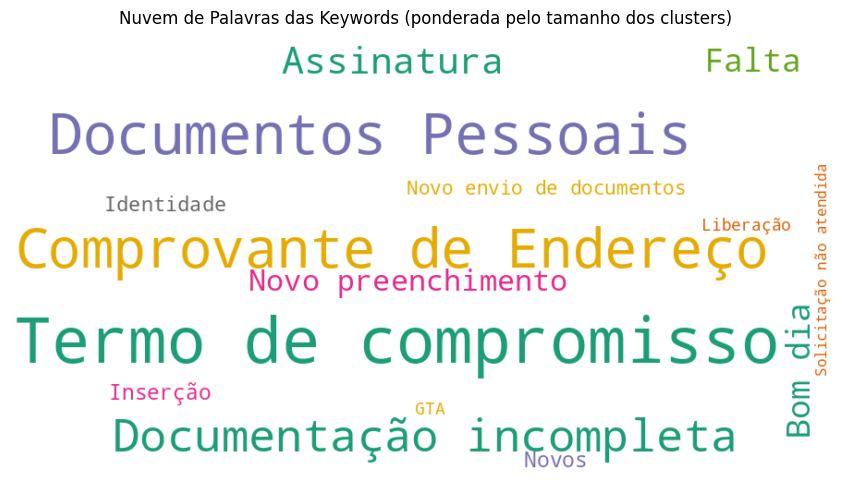

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

focus_map = {
    "Termo de responsabilidade": "Termo de compromisso",
    "Termo de Responsabilidade": "Termo de compromisso",
    "Comprovante de endereço": "Comprovante de Endereço",
    "Documentos pessoais": "Documentos Pessoais",
    "Documentação": "Documentos Pessoais",
    "Documentos": "Documentos Pessoais",
    "Faltando": "Falta"
}

# separar keywords
keywords_expanded = (
    clusters_df[["Keywords", "Size"]]
    .dropna()
    .assign(Keywords=lambda x: x["Keywords"].str.split(";"))
    .explode("Keywords")
)

keywords_expanded["Keywords"] = keywords_expanded["Keywords"].str.strip().replace(focus_map)

# calcular peso ponderado
keyword_weight = (
    keywords_expanded
    .groupby("Keywords")["Size"]
    .sum()
    .sort_values(ascending=False)
)

freq_dict = keyword_weight.to_dict()

colormap="Dark2"

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Dark2"
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras das Keywords (ponderada pelo tamanho dos clusters)")
plt.show()